<a href="https://colab.research.google.com/github/IvanParraR/Talleres-IA/blob/main/Taller7_KNN_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de dígitos escritos a mano con KNN y RNN

En este cuaderno diseñamos e implementamos dos clasificadores basados en vecinos
para reconocer dígitos manuscritos (0 a 9) usando el dataset `digits` de
scikit-learn:

* **KNN** (`KNeighborsClassifier`): vota entre los **K vecinos más cercanos**.
* **RNN** (`RadiusNeighborsClassifier`): vota entre los vecinos situados dentro
  de un **radio** fijo.

Metodología:

1. Separar los datos en **80 % entrenamiento / 20 % prueba**.
2. Ajustar los hiperparámetros (K y radio) usando **validación cruzada con
   K-fold = 4** sobre el conjunto de entrenamiento únicamente.
3. Elaborar una figura con las métricas de desempeño para un rango de valores
   de K (KNN) y de radio (RNN).
4. Seleccionar el valor con mejor desempeño en validación cruzada.
5. Entrenar el modelo final con ese hiperparámetro sobre **todo** el
   entrenamiento y evaluarlo **una sola vez** sobre el 20 % de prueba, que no
   participó en ninguna decisión anterior.


## 1. El dataset `digits`

`load_digits` contiene 1797 imágenes de dígitos manuscritos de 8×8 píxeles
(64 características por imagen), con niveles de gris entre 0 y 16. La
variable objetivo es el dígito real (0-9), por lo que este es un problema de
clasificación **multiclase** (10 clases).


In [ ]:
# Cargamos el dataset de dígitos incluido en scikit-learn.
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt

digits = load_digits()
X, y = digits.data, digits.target

# Inspección tamaño del dataset y balance de clases.
print(f"Forma de X: {X.shape}  (muestras, características)")
print(f"Clases presentes: {np.unique(y)}")
print(f"Muestras por clase:")
for clase in np.unique(y):
    print(f"  Dígito {clase}: {np.sum(y == clase)} muestras")


Forma de X: (1797, 64)  (muestras, características)
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Muestras por clase:
  Dígito 0: 178 muestras
  Dígito 1: 182 muestras
  Dígito 2: 177 muestras
  Dígito 3: 183 muestras
  Dígito 4: 181 muestras
  Dígito 5: 182 muestras
  Dígito 6: 181 muestras
  Dígito 7: 179 muestras
  Dígito 8: 174 muestras
  Dígito 9: 180 muestras


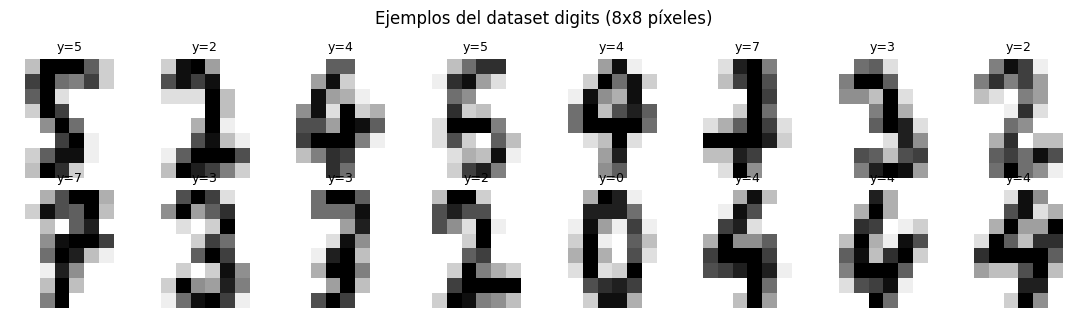

In [ ]:
# Mostramos algunos ejemplos del dataset
fig, axes = plt.subplots(2, 8, figsize=(11, 3.2))
rng = np.random.RandomState(1970)
indices_muestra = rng.choice(len(X), size=16, replace=False)
for ax, idx in zip(axes.ravel(), indices_muestra):
    ax.imshow(digits.images[idx], cmap='gray_r')
    ax.set_title(f"y={y[idx]}", fontsize=9)
    ax.axis('off')
fig.suptitle("Ejemplos del dataset digits (8x8 píxeles)")
fig.tight_layout()
plt.show()


## 2. División 80 % entrenamiento / 20 % prueba

La partición se hace de forma **estratificada** (`stratify=y`) para conservar
la proporción de cada dígito en entrenamiento y en prueba, dado que se trata
de 10 clases. El conjunto de prueba queda completamente aislado hasta la
evaluación final de cada clasificador.


In [ ]:
from sklearn.model_selection import train_test_split
# test_size=0.20 -> 80% entrenamiento / 20% prueba.
# stratify=y asegura que cada dígito mantenga su proporción en ambos conjuntos.
# random_state fija la partición para que el experimento sea reproducible.

X_train_original, X_test_original, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1970, stratify=y)

print(f"Entrenamiento: {len(X_train_original)} muestras "
      f"({len(X_train_original)/len(X):.0%})")
print(f"Prueba:        {len(X_test_original)} muestras "
      f"({len(X_test_original)/len(X):.0%})")


Entrenamiento: 1437 muestras (80%)
Prueba:        360 muestras (20%)


## 3. Estandarización

Aunque todos los píxeles comparten la misma escala (0-16), su varianza es muy
distinta: los píxeles del borde casi siempre son 0, mientras que los del
centro varían mucho entre dígitos. Estandarizamos (media 0, desviación 1)
para que ninguna característica domine el cálculo de distancias.

La media y la desviación estándar se calculan **solo con el entrenamiento**;
la misma transformación se aplica después a la prueba.


In [ ]:
from sklearn.preprocessing import StandardScaler

# fit_transform en entrenamiento: calcula media/desviación y transforma en un solo paso.
# transform (sin fit) en prueba: reutiliza la media/desviación aprendidas, sin "ver" la prueba.

escalador = StandardScaler()
X_train = escalador.fit_transform(X_train_original)
X_test = escalador.transform(X_test_original)


## 4. Validación cruzada con K-fold = 4

Para elegir los hiperparámetros usamos `StratifiedKFold(n_splits=4)`
**sobre el entrenamiento**: en cada iteración, 3 de los 4 pliegues se usan
para ajustar el modelo (incluido el escalador, dentro de un `Pipeline`, para
evitar fuga de información) y el pliegue restante para validar. El conjunto
de prueba del 20 % no interviene en esta etapa.

Como el problema es multiclase, usamos métricas con promedio macro (cada
clase pesa igual, sin importar cuántas muestras tenga):

$$\mathrm{Accuracy}=\frac{\text{predicciones correctas}}{\text{total de muestras}}$$

$$\mathrm{Precision_{macro}}=\frac{1}{10}\sum_{c=0}^{9}\mathrm{Precision}_c
\qquad
\mathrm{Recall_{macro}}=\frac{1}{10}\sum_{c=0}^{9}\mathrm{Recall}_c
\qquad
F1_{macro}=\frac{1}{10}\sum_{c=0}^{9} F1_c$$


## 5. KNN: rango de valores de K

Evaluamos **K = 1, 2, …, 30** con distancia euclidiana (Minkowski, p=2) y
votos ponderados por distancia (`weights='distance'`), usando validación
cruzada de 4 pliegues sobre el entrenamiento.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Configuración base del clasificador KNN (n_neighbors se irá cambiando en el bucle).
clfKNN = KNeighborsClassifier(weights='distance', algorithm='auto',
                               p=2, metric='minkowski')

valores_k = np.arange(1, 31, 1)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=1970)

# Métricas multiclase a registrar en cada pliegue (todas con promedio "macro").
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

resultados_k = {nombre: [] for nombre in scoring}

for k in valores_k:
    # Pipeline: el escalador se ajusta SOLO con los 3 pliegues de entrenamiento de cada iteración,
    # nunca con el pliegue de validación (evita fuga de información).

    modelo = Pipeline([
        ("escalador", StandardScaler()),
        ("knn", clone(clfKNN).set_params(n_neighbors=int(k))),
    ])
    scores = cross_validate(modelo, X_train_original, y_train, cv=cv,
                             scoring=scoring, n_jobs=1)
    for nombre in scoring:
        resultados_k[nombre].append(scores[f"test_{nombre}"])

# Convertimos las listas a arreglos de forma (n_valores_de_K, 4_folds) para graficar fácilmente.
resultados_k = {nombre: np.asarray(valores) for nombre, valores in resultados_k.items()}
print("Validación cruzada de KNN completada para", len(valores_k), "valores de K.")


Validación cruzada de KNN completada para 30 valores de K.


Métrica             K óptimo       Media    Desv. estándar
----------------------------------------------------------
accuracy                   4      0.9715            0.0047
f1_macro                   4      0.9713            0.0048
precision_macro            4      0.9719            0.0047
recall_macro               4      0.9714            0.0047


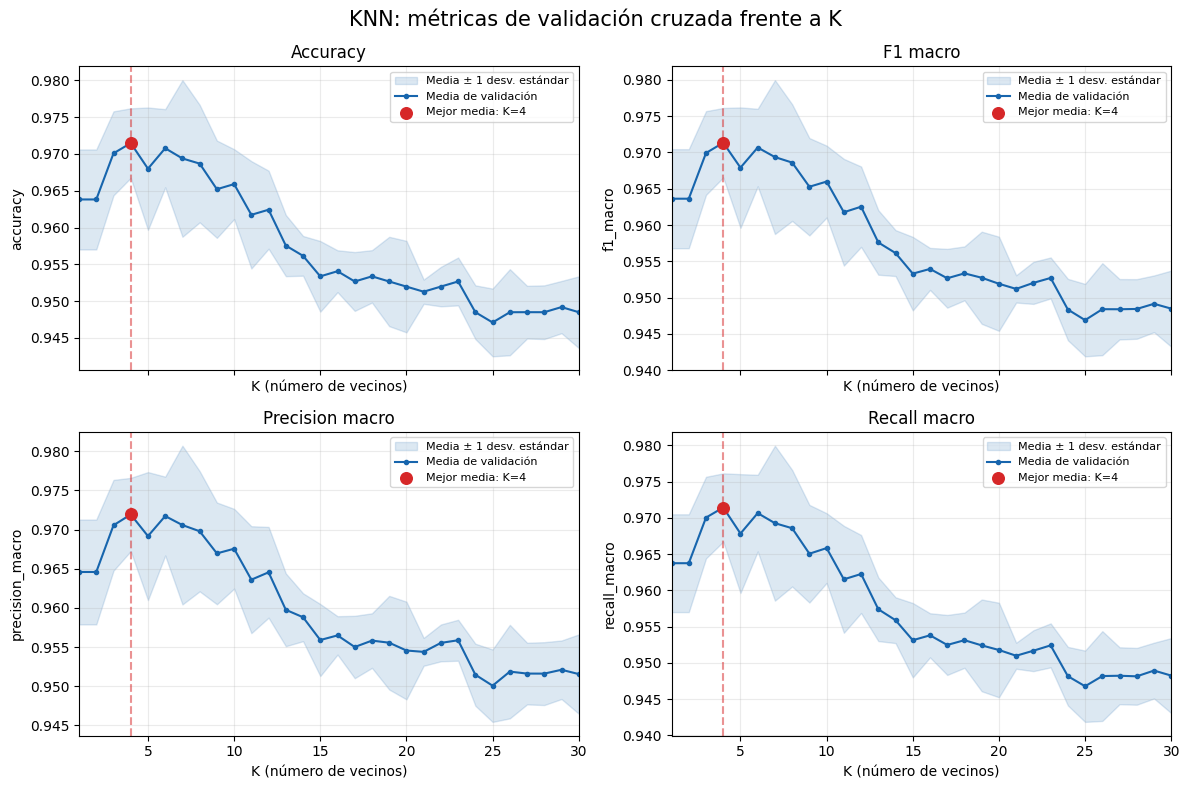

In [ ]:
configuracion_k = [
    ("accuracy", "Accuracy"),
    ("f1_macro", "F1 macro"),
    ("precision_macro", "Precision macro"),
    ("recall_macro", "Recall macro"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

mejores_k = {}
print(f"{'Métrica':<18}{'K óptimo':>10}{'Media':>12}{'Desv. estándar':>18}")
print("-" * 58)

for ax, (nombre, titulo) in zip(axes.ravel(), configuracion_k):
    valores = resultados_k[nombre]
    media = valores.mean(axis=1)
    desviacion = valores.std(axis=1, ddof=1)
    indice = np.argmax(media)
    k_optimo = int(valores_k[indice])
    mejores_k[nombre] = k_optimo

    ax.fill_between(valores_k, media - desviacion, media + desviacion,
                     color="#1765ad", alpha=0.15, label="Media ± 1 desv. estándar")
    ax.plot(valores_k, media, "o-", color="#1765ad", markersize=3,
             label="Media de validación")
    ax.scatter(k_optimo, media[indice], color="#d62728", s=70, zorder=5,
               label=f"Mejor media: K={k_optimo}")
    ax.axvline(k_optimo, color="#d62728", linestyle="--", alpha=0.5)
    ax.set(title=titulo, xlabel="K (número de vecinos)", ylabel=nombre,
           xlim=(1, 30))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    print(f"{nombre:<18}{k_optimo:>10d}{media[indice]:>12.4f}{desviacion[indice]:>18.4f}")

fig.suptitle("KNN: métricas de validación cruzada frente a K", fontsize=15)
fig.tight_layout()
plt.show()


### Selección del mejor K

Usamos **accuracy media en validación cruzada** como criterio principal
(las cuatro métricas coinciden en un rango muy similar de K, ya que las
clases están balanceadas). El valor elegido se usará para entrenar el
modelo final.


In [ ]:
K_OPTIMO = mejores_k["accuracy"]
print(f"K seleccionado (mejor accuracy media en CV): {K_OPTIMO}")


K seleccionado (mejor accuracy media en CV): 4


## 6. KNN: evaluación final sobre el conjunto de prueba

Entrenamos el modelo con `K_OPTIMO` usando **todo** el entrenamiento
(ya estandarizado) y lo evaluamos **una sola vez** sobre el 20 % de prueba,
que hasta ahora no había participado en ninguna decisión.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

clfKNN_final = clone(clfKNN).set_params(n_neighbors=int(K_OPTIMO))
clfKNN_final.fit(X_train, y_train)
y_pred_knn = clfKNN_final.predict(X_test)

print(f"KNN (K={K_OPTIMO}) — métricas sobre el 20% de prueba")
print("-" * 50)
print(f"Accuracy:         {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision macro:  {precision_score(y_test, y_pred_knn, average='macro'):.4f}")
print(f"Recall macro:     {recall_score(y_test, y_pred_knn, average='macro'):.4f}")
print(f"F1 macro:         {f1_score(y_test, y_pred_knn, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_knn, digits=3))


KNN (K=4) — métricas sobre el 20% de prueba
--------------------------------------------------
Accuracy:         0.9806
Precision macro:  0.9811
Recall macro:     0.9805
F1 macro:         0.9805

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        36
           1      1.000     1.000     1.000        37
           2      0.972     1.000     0.986        35
           3      0.947     0.973     0.960        37
           4      0.973     1.000     0.986        36
           5      0.947     1.000     0.973        36
           6      1.000     1.000     1.000        36
           7      1.000     0.972     0.986        36
           8      1.000     0.943     0.971        35
           9      0.971     0.917     0.943        36

    accuracy                          0.981       360
   macro avg      0.981     0.980     0.980       360
weighted avg      0.981     0.981     0.980       360



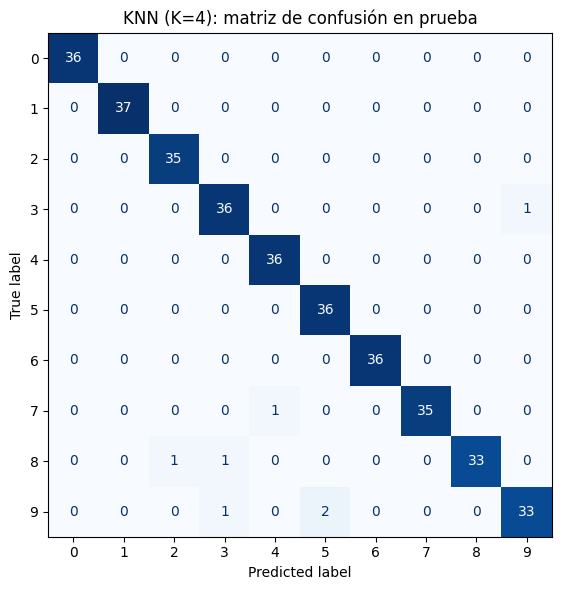

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn),
                       display_labels=range(10)).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"KNN (K={K_OPTIMO}): matriz de confusión en prueba")
fig.tight_layout()
plt.show()


## 7. RNN: rango de valores de radio

A diferencia de KNN, en el clasificador por radio cada consulta puede tener
un número distinto de vecinos, incluso ninguno. Para elegir un rango de
radios razonable, observamos la distancia (en el espacio estandarizado) a
los primeros vecinos de cada muestra de entrenamiento.


In [ ]:
from sklearn.neighbors import NearestNeighbors

nn_exploratorio = NearestNeighbors(n_neighbors=6).fit(X_train)
distancias, _ = nn_exploratorio.kneighbors(X_train)
# columna 0 es la distancia a sí mismo (0); usamos del vecino 1 al 5
percentiles = np.percentile(distancias[:, 1:], [5, 25, 50, 75, 95], axis=0)

print("Percentiles de distancia (5, 25, 50, 75, 95) a los vecinos 1..5:")
for i, fila in enumerate(percentiles):
    print(f"  Percentil {[5,25,50,75,95][i]:>2}%: {np.round(fila, 2)}")


Percentiles de distancia (5, 25, 50, 75, 95) a los vecinos 1..5:
  Percentil  5%: [2.39 2.79 2.99 3.14 3.23]
  Percentil 25%: [3.05 3.44 3.66 3.83 3.96]
  Percentil 50%: [3.58 3.94 4.2  4.38 4.52]
  Percentil 75%: [4.13 4.6  4.89 5.05 5.24]
  Percentil 95%: [5.44 6.05 6.37 6.6  6.81]


Las distancias al primer vecino más cercano se ubican, en su mayoría,
entre 2 y 7 unidades estandarizadas. Con base en esto, exploramos radios
entre **2.0 y 12.0**, en pasos de **0.5**: valores más pequeños dejarían a
muchas muestras sin ningún vecino, y valores mucho mayores mezclarían
dígitos distintos en el mismo vecindario.

Usamos `outlier_label='most_frequent'` para asignar la clase más frecuente
del vecindario de entrenamiento a las consultas que no tengan ningún vecino
dentro del radio (en vez de fallar), y registramos además:

* **Cobertura**: fracción de muestras evaluadas que sí tuvieron al menos un
  vecino dentro del radio.
* **Vecinos medios**: número promedio de vecinos encontrados por muestra.

$$\text{Cobertura}(r)=\frac{\text{muestras con al menos un vecino}}
{\text{total de muestras evaluadas}}$$


In [ ]:
from sklearn.neighbors import RadiusNeighborsClassifier
import warnings

clfRNN = RadiusNeighborsClassifier(weights='distance', algorithm='auto', p=2,
                                    metric='minkowski',
                                    outlier_label='most_frequent')

valores_r = np.round(np.arange(2.0, 12.1, 0.5), 2)
nombres_r = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro',
             'cobertura', 'vecinos_medios']
resultados_r = {nombre: np.zeros((len(valores_r), 4)) for nombre in nombres_r}

for fold, (idx_ent, idx_val) in enumerate(cv.split(X_train_original, y_train)):
    esc_fold = StandardScaler()
    x_ent = esc_fold.fit_transform(X_train_original[idx_ent])
    x_val = esc_fold.transform(X_train_original[idx_val])
    y_ent, y_val = y_train[idx_ent], y_train[idx_val]

    for j, r in enumerate(valores_r):
        modelo = clone(clfRNN).set_params(radius=float(r))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            modelo.fit(x_ent, y_ent)
            pred = modelo.predict(x_val)
            vecinos = modelo.radius_neighbors(x_val, return_distance=False)
        cantidades = np.array([len(v) for v in vecinos])

        valores_fold = [
            accuracy_score(y_val, pred),
            f1_score(y_val, pred, average='macro', zero_division=0),
            precision_score(y_val, pred, average='macro', zero_division=0),
            recall_score(y_val, pred, average='macro', zero_division=0),
            np.mean(cantidades > 0),
            cantidades.mean(),
        ]
        for nombre, valor in zip(nombres_r, valores_fold):
            resultados_r[nombre][j, fold] = valor

print("Validación cruzada de RNN completada para", len(valores_r), "valores de radio.")


Validación cruzada de RNN completada para 21 valores de radio.


Métrica             Radio óptimo       Media    Desv. estándar
--------------------------------------------------------------
accuracy                    6.50      0.9353            0.0041
f1_macro                    6.00      0.9360            0.0125
precision_macro             6.00      0.9451            0.0092
recall_macro                6.50      0.9350            0.0045


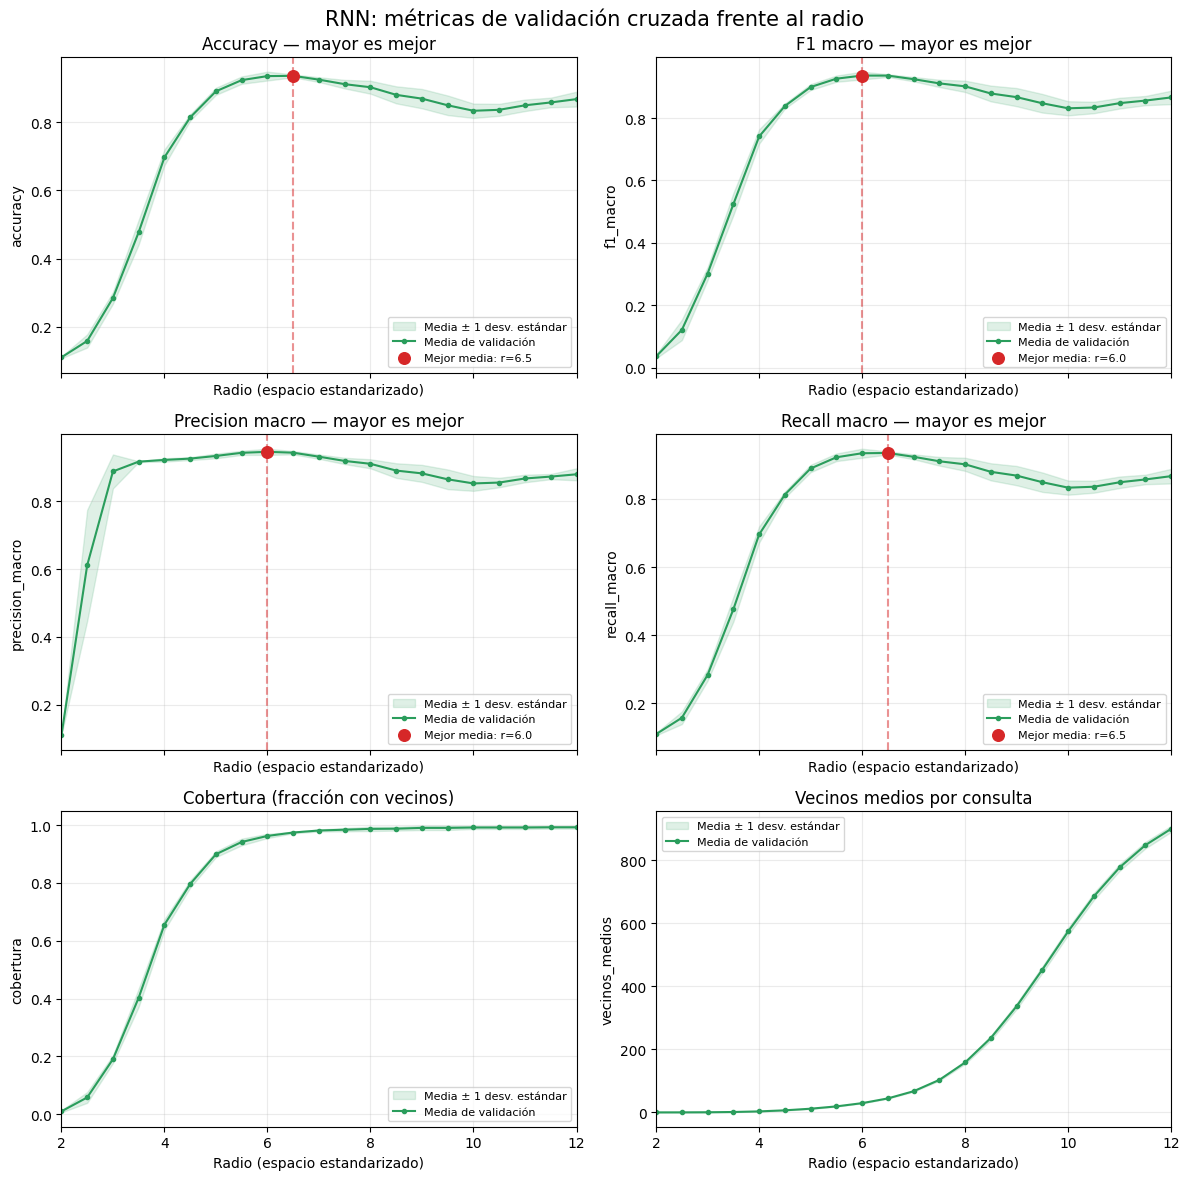

In [ ]:
configuracion_r = [
    ("accuracy", "Accuracy — mayor es mejor"),
    ("f1_macro", "F1 macro — mayor es mejor"),
    ("precision_macro", "Precision macro — mayor es mejor"),
    ("recall_macro", "Recall macro — mayor es mejor"),
    ("cobertura", "Cobertura (fracción con vecinos)"),
    ("vecinos_medios", "Vecinos medios por consulta"),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)

mejores_r = {}
print(f"{'Métrica':<18}{'Radio óptimo':>14}{'Media':>12}{'Desv. estándar':>18}")
print("-" * 62)

for ax, (nombre, titulo) in zip(axes.ravel(), configuracion_r):
    valores = resultados_r[nombre]
    media = valores.mean(axis=1)
    desviacion = valores.std(axis=1, ddof=1)

    ax.fill_between(valores_r, media - desviacion, media + desviacion,
                     color="#2a9d5c", alpha=0.15, label="Media ± 1 desv. estándar")
    ax.plot(valores_r, media, "o-", color="#2a9d5c", markersize=3,
             label="Media de validación")

    if nombre not in ("cobertura", "vecinos_medios"):
        indice = np.argmax(media)
        r_optimo = valores_r[indice]
        mejores_r[nombre] = r_optimo
        ax.scatter(r_optimo, media[indice], color="#d62728", s=70, zorder=5,
                   label=f"Mejor media: r={r_optimo:.1f}")
        ax.axvline(r_optimo, color="#d62728", linestyle="--", alpha=0.5)
        print(f"{nombre:<18}{r_optimo:>14.2f}{media[indice]:>12.4f}{desviacion[indice]:>18.4f}")

    ax.set(title=titulo, xlabel="Radio (espacio estandarizado)", ylabel=nombre,
           xlim=(valores_r.min(), valores_r.max()))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("RNN: métricas de validación cruzada frente al radio", fontsize=15)
fig.tight_layout()
plt.show()


### Selección del mejor radio

Igual que con KNN, usamos la **accuracy media en validación cruzada** como
criterio principal para elegir el radio final, verificando que la cobertura
en ese punto sea razonablemente alta (es decir, que la mayoría de las
consultas sí encuentren vecinos dentro del radio elegido, y no dependan de
la regla de respaldo `outlier_label='most_frequent'`).


In [ ]:
R_OPTIMO = mejores_r["accuracy"]
indice_r_optimo = int(np.where(valores_r == R_OPTIMO)[0][0])
cobertura_en_optimo = resultados_r["cobertura"][indice_r_optimo].mean()

print(f"Radio seleccionado (mejor accuracy media en CV): {R_OPTIMO}")
print(f"Cobertura media en ese radio: {cobertura_en_optimo:.2%}")


Radio seleccionado (mejor accuracy media en CV): 6.5
Cobertura media en ese radio: 97.43%


## 8. RNN: evaluación final sobre el conjunto de prueba

Entrenamos el modelo con `R_OPTIMO` sobre todo el entrenamiento estandarizado
y lo evaluamos sobre el 20 % de prueba.


In [ ]:
clfRNN_final = clone(clfRNN).set_params(radius=float(R_OPTIMO))
clfRNN_final.fit(X_train, y_train)
y_pred_rnn = clfRNN_final.predict(X_test)

vecinos_prueba = clfRNN_final.radius_neighbors(X_test, return_distance=False)
cobertura_prueba = np.mean([len(v) > 0 for v in vecinos_prueba])

print(f"RNN (radio={R_OPTIMO}) — métricas sobre el 20% de prueba")
print("-" * 50)
print(f"Accuracy:         {accuracy_score(y_test, y_pred_rnn):.4f}")
print(f"Precision macro:  {precision_score(y_test, y_pred_rnn, average='macro'):.4f}")
print(f"Recall macro:     {recall_score(y_test, y_pred_rnn, average='macro'):.4f}")
print(f"F1 macro:         {f1_score(y_test, y_pred_rnn, average='macro'):.4f}")
print(f"Cobertura:        {cobertura_prueba:.2%}")
print()
print(classification_report(y_test, y_pred_rnn, digits=3))


RNN (radio=6.5) — métricas sobre el 20% de prueba
--------------------------------------------------
Accuracy:         0.9528
Precision macro:  0.9562
Recall macro:     0.9528
F1 macro:         0.9537
Cobertura:        97.78%

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        36
           1      0.974     1.000     0.987        37
           2      1.000     1.000     1.000        35
           3      0.786     0.892     0.835        37
           4      1.000     0.889     0.941        36
           5      0.944     0.944     0.944        36
           6      1.000     1.000     1.000        36
           7      0.946     0.972     0.959        36
           8      0.941     0.914     0.928        35
           9      0.971     0.917     0.943        36

    accuracy                          0.953       360
   macro avg      0.956     0.953     0.954       360
weighted avg      0.956     0.953     0.953       360



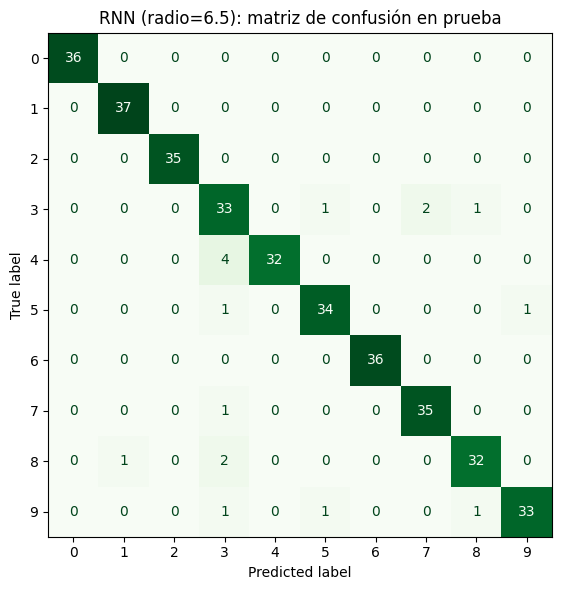

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rnn),
                       display_labels=range(10)).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f"RNN (radio={R_OPTIMO}): matriz de confusión en prueba")
fig.tight_layout()
plt.show()


## 9. Comparación final

Ambos modelos se seleccionaron con el mismo protocolo (K-fold = 4 sobre el
80 % de entrenamiento) y se evaluaron una única vez sobre el mismo 20 % de
prueba, por lo que la comparación es justa.


In [ ]:
comparacion = {
    "Modelo": ["KNN", "RNN"],
    "Hiperparámetro": [f"K={K_OPTIMO}", f"radio={R_OPTIMO}"],
    "Accuracy": [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rnn)],
    "F1 macro": [f1_score(y_test, y_pred_knn, average='macro'),
                 f1_score(y_test, y_pred_rnn, average='macro')],
    "Precision macro": [precision_score(y_test, y_pred_knn, average='macro'),
                        precision_score(y_test, y_pred_rnn, average='macro')],
    "Recall macro": [recall_score(y_test, y_pred_knn, average='macro'),
                     recall_score(y_test, y_pred_rnn, average='macro')],
}

print(f"{'Modelo':<8}{'Hiperparámetro':<16}{'Accuracy':>10}{'F1 macro':>11}"
      f"{'Precision':>12}{'Recall':>10}")
for i in range(2):
    print(f"{comparacion['Modelo'][i]:<8}{comparacion['Hiperparámetro'][i]:<16}"
          f"{comparacion['Accuracy'][i]:>10.4f}{comparacion['F1 macro'][i]:>11.4f}"
          f"{comparacion['Precision macro'][i]:>12.4f}{comparacion['Recall macro'][i]:>10.4f}")


Modelo  Hiperparámetro    Accuracy   F1 macro   Precision    Recall
KNN     K=4                 0.9806     0.9805      0.9811    0.9805
RNN     radio=6.5           0.9528     0.9537      0.9562    0.9528


**Observaciones:**

* Sobre imágenes de 8×8 (64 características), con una buena estandarización,
  tanto KNN como RNN alcanzan un desempeño alto en el dataset `digits`.
* KNN es más robusto en este problema porque garantiza un número fijo de
  vecinos para cada consulta (siempre vota entre K vecinos), mientras que RNN
  depende de que el radio elegido sea adecuado para la densidad local de los
  datos; radios pequeños dejan muchas muestras sin vecinos (baja cobertura) y
  radios grandes mezclan dígitos distintos en el mismo vecindario.
* En ambos casos, el hiperparámetro se seleccionó **únicamente** con
  validación cruzada sobre el entrenamiento; el conjunto de prueba solo se
  usó al final, una vez, para estimar el desempeño real de cada modelo.
